Purpose: Re-make figures & re-run downstream analyses for ASE run by genotype and treatment, rather than just genotype.<br>
Author: Anna Pardo<br>
Date initiated: Apr. 17, 2026

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
from matplotlib.colors import LinearSegmentedColormap

In [2]:
# load HEB DESeq results
degs = pd.read_csv("./ASE_gttreat_output.txt",sep="\t",header="infer")
degs.head()

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,GeneID,Contrast
0,67.211469,0.764897,0.089259,8.569367,1.040554e-17,4.892090e-17,recip_syn2,18_W_aloifolia-V-18_W_filamentosa
1,207.226297,-0.485237,0.071331,-6.802606,1.027436e-11,3.495057e-11,recip_syn3,18_W_aloifolia-V-18_W_filamentosa
2,43.434762,0.344017,0.106880,3.218711,1.287680e-03,2.321305e-03,recip_syn4,18_W_aloifolia-V-18_W_filamentosa
3,52.217998,-1.184873,0.103213,-11.479849,1.665721e-30,1.346501e-29,recip_syn5,18_W_aloifolia-V-18_W_filamentosa
4,390.928299,-0.320654,0.073987,-4.333917,1.464794e-05,3.195546e-05,recip_syn7,18_W_aloifolia-V-18_W_filamentosa


In [3]:
dbase = "/home/leviathan22/Yucca_genomics/"

In [4]:
# note Ya is reference for all comparisons
## load syntelog data
syn = pd.read_csv(os.path.join(dbase,"yucca_synteny/reciprocal_syntelogs_sameinYaYf.txt"),sep="\t",header="infer")
syn.head()

,Yf_GeneID,Ya_GeneID,syntelogID
0,YufilH1000002m.g,Yucal.01G000100.v2.1,recip_syn1
1,YufilH1000007m.g,Yucal.01G000200.v2.1,recip_syn2
2,YufilH1000011m.g,Yucal.01G000400.v2.1,recip_syn3
3,YufilH1000013m.g,Yucal.01G000500.v2.1,recip_syn4
4,YufilH1000018m.g,Yucal.01G000600.v2.1,recip_syn5


In [5]:
degs.rename(columns={"GeneID":"syntelogID"},inplace=True)

In [6]:
# merge syntelog data with results
res = degs.merge(syn)
res.head()

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,syntelogID,Contrast,Yf_GeneID,Ya_GeneID
0,67.211469,0.764897,0.089259,8.569367,1.040554e-17,4.892090e-17,recip_syn2,18_W_aloifolia-V-18_W_filamentosa,YufilH1000007m.g,Yucal.01G000200.v2.1
1,67.211469,1.041007,0.096986,10.733621,7.076770e-27,4.864905e-26,recip_syn2,2AB_W_aloifolia-V-2AB_W_filamentosa,YufilH1000007m.g,Yucal.01G000200.v2.1
2,67.211469,0.825842,0.086364,9.562370,1.150902e-21,5.656733e-21,recip_syn2,2AB_D_aloifolia-V-2AB_D_filamentosa,YufilH1000007m.g,Yucal.01G000200.v2.1
3,67.211469,0.959057,0.096610,9.927104,3.173384e-23,2.005232e-22,recip_syn2,1AB_W_aloifolia-V-1AB_W_filamentosa,YufilH1000007m.g,Yucal.01G000200.v2.1
4,67.211469,0.924623,0.087605,10.554497,4.842263e-26,3.179247e-25,recip_syn2,18_D_aloifolia-V-18_D_filamentosa,YufilH1000007m.g,Yucal.01G000200.v2.1


In [7]:
# create a genotype column & a treatment column
gt = []
treat = []
for i in list(res["Contrast"]):
    gt.append(i.split("_")[0])
    treat.append(i.split("_")[1])
res["genotype"] = gt
res["treat"] = treat
res.head()

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,syntelogID,Contrast,Yf_GeneID,Ya_GeneID,genotype,treat
0,67.211469,0.764897,0.089259,8.569367,1.040554e-17,4.892090e-17,recip_syn2,18_W_aloifolia-V-18_W_filamentosa,YufilH1000007m.g,Yucal.01G000200.v2.1,18,W
1,67.211469,1.041007,0.096986,10.733621,7.076770e-27,4.864905e-26,recip_syn2,2AB_W_aloifolia-V-2AB_W_filamentosa,YufilH1000007m.g,Yucal.01G000200.v2.1,2AB,W
2,67.211469,0.825842,0.086364,9.562370,1.150902e-21,5.656733e-21,recip_syn2,2AB_D_aloifolia-V-2AB_D_filamentosa,YufilH1000007m.g,Yucal.01G000200.v2.1,2AB,D
3,67.211469,0.959057,0.096610,9.927104,3.173384e-23,2.005232e-22,recip_syn2,1AB_W_aloifolia-V-1AB_W_filamentosa,YufilH1000007m.g,Yucal.01G000200.v2.1,1AB,W
4,67.211469,0.924623,0.087605,10.554497,4.842263e-26,3.179247e-25,recip_syn2,18_D_aloifolia-V-18_D_filamentosa,YufilH1000007m.g,Yucal.01G000200.v2.1,18,D


In [8]:
# make a Regulation column
reg = []
for i in list(res["log2FoldChange"]):
    if i<0:
        reg.append("Ya_biased")
    elif i>0:
        reg.append("Yf_biased")
res["ASE"] = reg

In [9]:
biascount = res.groupby(["genotype","treat","ASE"]).count().reset_index()[["genotype","treat","ASE","syntelogID"]].rename(
    columns={"syntelogID":"number of gene pairs"}
)
biascount.head()

,genotype,treat,ASE,number of gene pairs
0,13,D,Ya_biased,5283
1,13,D,Yf_biased,5285
2,13,W,Ya_biased,8545
3,13,W,Yf_biased,8484
4,15,W,Ya_biased,6861


In [10]:
bcp = biascount.pivot(["genotype","treat"],"ASE","number of gene pairs").reset_index()
bcp.head()

ASE,genotype,treat,Ya_biased,Yf_biased
0,13,D,5283,5285
1,13,W,8545,8484
2,15,W,6861,6667
3,18,D,8846,8861
4,18,W,8788,8756


In [11]:
# load the physiology dict
phys = json.load(open("/home/leviathan22/yucca-genomics/physiology/physiological_categories_from_TA.json"))

In [12]:
bcp["CAMphys"] = bcp["genotype"].map(phys)

In [13]:
bcp.head()

ASE,genotype,treat,Ya_biased,Yf_biased,CAMphys
0,13,D,5283,5285,facultative CAM
1,13,W,8545,8484,facultative CAM
2,15,W,6861,6667,facultative CAM
3,18,D,8846,8861,C3+CAM
4,18,W,8788,8756,C3+CAM


In [14]:
biascount["CAMphys"] = biascount["genotype"].map(phys)
biascount.sort_values(["CAMphys","genotype","treat"],inplace=True)

In [15]:
biascount.head()

,genotype,treat,ASE,number of gene pairs,CAMphys
6,18,D,Ya_biased,8846,C3+CAM
7,18,D,Yf_biased,8861,C3+CAM
8,18,W,Ya_biased,8788,C3+CAM
9,18,W,Yf_biased,8756,C3+CAM
10,19,D,Ya_biased,8063,C3+CAM


In [16]:
# save biascount to a file - do statistics in R
biascount.to_csv("./ASE_gttreat_ngenesbiased.txt",sep="\t",header=True,index=False)

In [17]:
# plot gene numbers by treatment & bias
biascount["bias_treat"] = biascount["ASE"]+"_"+biascount["treat"]

In [18]:
biascount = biascount.sort_values(by=["treat","ASE","CAMphys"],ascending=False)

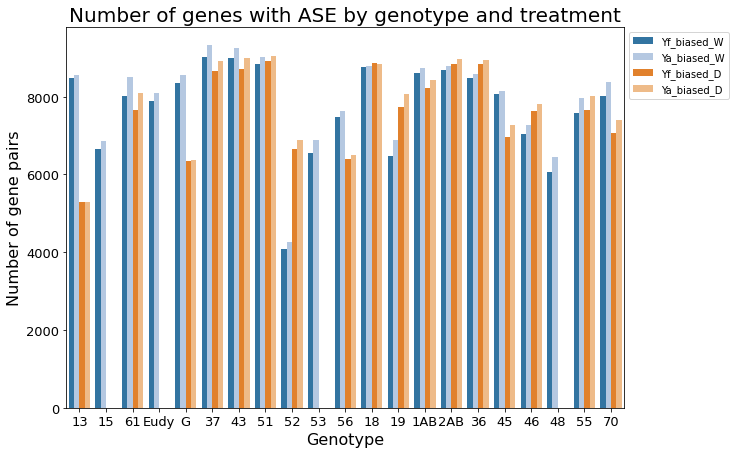

In [19]:
fig,ax = plt.subplots(figsize=(10,7))
sns.barplot(data=biascount,y="number of gene pairs",x="genotype",hue="bias_treat",palette="tab20")
ax.legend(bbox_to_anchor=(1,1))
ax.tick_params(which="both",labelsize=13)
plt.xlabel("Genotype",fontsize=16)
plt.ylabel("Number of gene pairs",fontsize=16)
plt.title("Number of genes with ASE by genotype and treatment",fontsize=20)
plt.savefig("./deseq_ASE_gttreat_ngenes.png",dpi=300,bbox_inches="tight")
plt.savefig("./deseq_ASE_gttreat_ngenes.pdf",dpi=300,bbox_inches="tight")
plt.savefig("./deseq_ASE_gttreat_ngenes.svg",dpi=300,bbox_inches="tight")

In [20]:
min(biascount["number of gene pairs"])

4085

In [21]:
max(biascount["number of gene pairs"])

9319

In [22]:
biascount[["genotype","CAMphys"]].drop_duplicates()

,genotype,CAMphys
3,13,facultative CAM
5,15,facultative CAM
65,61,facultative CAM
71,Eudy,facultative CAM
75,G,facultative CAM
29,37,CAM
33,43,CAM
47,51,CAM
51,52,CAM
53,53,CAM


In [23]:
# load CAM gene annotation
cam = pd.read_csv("/home/leviathan22/Yucca_genomics/rna_insilico_genome/degs_downstream/camgenes_Ya_Yf_orthology_synteny.txt",
                 sep="\t",header="infer")
cam.head()

,GeneID,Orthogroup,Pathway,gene_name,gene_abbr,gene_abbr_unique,subgenome
0,Yucal.01G165600.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_1,Ya
1,Yucal.02G112700.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_2,Ya
2,Yucal.04G001000.v2.1,OG0004406,CAM-dark,beta-carbonic anhydrase,bCA5,Ya_bCA5_1,Ya
3,Yucal.07G000800.v2.1,OG0004406,CAM-dark,beta-carbonic anhydrase,bCA5,Ya_bCA5_2,Ya
4,Yucal.03G120900.v2.1,OG0002899,CAM-dark,NAD-dependent malate dehydrogenase (chloroplas...,NAD-MDH-cp,Ya_NAD-MDH-cp_1,Ya


In [24]:
res["ASE"] = res["ASE"].str.split("_").str[0]
res.head()

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,syntelogID,Contrast,Yf_GeneID,Ya_GeneID,genotype,treat,ASE
0,67.211469,0.764897,0.089259,8.569367,1.040554e-17,4.892090e-17,recip_syn2,18_W_aloifolia-V-18_W_filamentosa,YufilH1000007m.g,Yucal.01G000200.v2.1,18,W,Yf
1,67.211469,1.041007,0.096986,10.733621,7.076770e-27,4.864905e-26,recip_syn2,2AB_W_aloifolia-V-2AB_W_filamentosa,YufilH1000007m.g,Yucal.01G000200.v2.1,2AB,W,Yf
2,67.211469,0.825842,0.086364,9.562370,1.150902e-21,5.656733e-21,recip_syn2,2AB_D_aloifolia-V-2AB_D_filamentosa,YufilH1000007m.g,Yucal.01G000200.v2.1,2AB,D,Yf
3,67.211469,0.959057,0.096610,9.927104,3.173384e-23,2.005232e-22,recip_syn2,1AB_W_aloifolia-V-1AB_W_filamentosa,YufilH1000007m.g,Yucal.01G000200.v2.1,1AB,W,Yf
4,67.211469,0.924623,0.087605,10.554497,4.842263e-26,3.179247e-25,recip_syn2,18_D_aloifolia-V-18_D_filamentosa,YufilH1000007m.g,Yucal.01G000200.v2.1,18,D,Yf


In [25]:
# put res into a longer format
## first, subset some columns
reslong = res[["syntelogID","Yf_GeneID","Ya_GeneID","genotype","treat","ASE"]]
reslong.head()

,syntelogID,Yf_GeneID,Ya_GeneID,genotype,treat,ASE
0,recip_syn2,YufilH1000007m.g,Yucal.01G000200.v2.1,18,W,Yf
1,recip_syn2,YufilH1000007m.g,Yucal.01G000200.v2.1,2AB,W,Yf
2,recip_syn2,YufilH1000007m.g,Yucal.01G000200.v2.1,2AB,D,Yf
3,recip_syn2,YufilH1000007m.g,Yucal.01G000200.v2.1,1AB,W,Yf
4,recip_syn2,YufilH1000007m.g,Yucal.01G000200.v2.1,18,D,Yf


In [26]:
dflist = []
for i in ["Ya","Yf"]:
    df = reslong[reslong["ASE"]==i][[i+"_GeneID","syntelogID","genotype","treat","ASE"]]
    df = df.rename(columns={i+"_GeneID":"GeneID","ASE":"subgenome"})
    df = df.merge(cam[["GeneID","subgenome","gene_abbr_unique","gene_abbr","Pathway"]])
    dflist.append(df)
hebcam = pd.concat(dflist)
hebcam.head()

,GeneID,syntelogID,genotype,treat,subgenome,gene_abbr_unique,gene_abbr,Pathway
0,Yucal.02G133400.v2.1,recip_syn3801,18,W,Ya,Ya_NADP-ME_2,NADP-ME,CAM-light
1,Yucal.02G133400.v2.1,recip_syn3801,2AB,W,Ya,Ya_NADP-ME_2,NADP-ME,CAM-light
2,Yucal.02G133400.v2.1,recip_syn3801,2AB,D,Ya,Ya_NADP-ME_2,NADP-ME,CAM-light
3,Yucal.02G133400.v2.1,recip_syn3801,1AB,W,Ya,Ya_NADP-ME_2,NADP-ME,CAM-light
4,Yucal.02G133400.v2.1,recip_syn3801,18,D,Ya,Ya_NADP-ME_2,NADP-ME,CAM-light


In [27]:
# create another dataframe to rename the syntelog pairs so we can fix the y axis of the plot
## create wide CAM data
dfl = []
for i in ["Ya","Yf"]:
    df = cam[cam["subgenome"]==i][["GeneID","gene_abbr_unique"]]
    df.rename(columns={"GeneID":i+"_GeneID","gene_abbr_unique":i+"_genename"},inplace=True)
    dfl.append(df)
for i in dfl:
    syn = syn.merge(i)
syn.head()

,Yf_GeneID,Ya_GeneID,syntelogID,Ya_genename,Yf_genename
0,YufilH1001781m.g,Yucal.01G077800.v2.1,recip_syn679,Ya_PPPC_1,Yf_PPPC_1
1,YufilH1003177m.g,Yucal.01G137500.v2.1,recip_syn1199,Ya_NADP-ME_1,Yf_NADP-ME_1
2,YufilH1003887m.g,Yucal.01G165600.v2.1,recip_syn1434,Ya_bCA1234_1,Yf_bCA1234_2
3,YufilH1011201m.g,Yucal.02G112700.v2.1,recip_syn3628,Ya_bCA1234_2,Yf_bCA1234_3
4,YufilH1011679m.g,Yucal.02G133400.v2.1,recip_syn3801,Ya_NADP-ME_2,Yf_NADP-ME_2


In [28]:
# set up syntelog pair names
synnames = {}
for i in range(len(syn.index)):
    sid = syn.iloc[i,2]
    yaid = syn.iloc[i,3].lstrip("Ya_")
    yfid = syn.iloc[i,4].lstrip("Yf_")
    
    if len(yaid.split("_"))==1:
        yaid = yaid+"_1"
    if len(yfid.split("_"))==1:
        yfid = yfid+"_1"
    
    if yaid == yfid:
        synnames[sid] = yaid
    else:
        synnames[sid] = yaid+"/"+yfid.split("_")[1]

In [29]:
synnames

{'recip_syn679': 'PPPC_1',
 'recip_syn1199': 'NADP-ME_1',
 'recip_syn1434': 'bCA1234_1/2',
 'recip_syn3628': 'bCA1234_2/3',
 'recip_syn3801': 'NADP-ME_2',
 'recip_syn6047': 'NAD-ME_1',
 'recip_syn6335': 'NAD-MDH-cp_1',
 'recip_syn6893': 'NAD-MDH-ct_1/2',
 'recip_syn7619': 'bCA5_1',
 'recip_syn8053': 'NAD-ME_2',
 'recip_syn8179': 'NAD-MDH-cp_2',
 'recip_syn9117': 'PPCK_2/1',
 'recip_syn10390': 'PPCK_4/2',
 'recip_syn11445': 'NAD-MDH-cp_3',
 'recip_syn12457': 'PPPC_2',
 'recip_syn13016': 'NADP-ME_3',
 'recip_syn13926': 'bCA5_2/4',
 'recip_syn14298': 'NADP-ME_4',
 'recip_syn14378': 'PPPC_3',
 'recip_syn14735': 'BPPC_1',
 'recip_syn21197': 'PPDK_1',
 'recip_syn23299': 'NADP-MDH_1',
 'recip_syn23442': 'NAD-MDH-ct_2/3',
 'recip_syn23445': 'PPCK_6/4',
 'recip_syn24603': 'PPCK_7/5',
 'recip_syn24607': 'NAD-MDH-ct_3/4',
 'recip_syn25868': 'NAD-MDH-cp_4',
 'recip_syn28164': 'PPPC_4',
 'recip_syn28241': 'NADP-ME_5/6',
 'recip_syn29627': 'PEPCK_2/1',
 'recip_syn29670': 'NADP-ME_6/7'}

In [30]:
with open("./rename_CAM_syntelogs.json","w+") as outfile:
    json.dump(synnames,outfile)

In [31]:
len(synnames.values())

31

In [32]:
hebcam["syntelog_name"] = hebcam["syntelogID"].map(synnames)

In [33]:
hebcam.head()

,GeneID,syntelogID,genotype,treat,subgenome,gene_abbr_unique,gene_abbr,Pathway,syntelog_name
0,Yucal.02G133400.v2.1,recip_syn3801,18,W,Ya,Ya_NADP-ME_2,NADP-ME,CAM-light,NADP-ME_2
1,Yucal.02G133400.v2.1,recip_syn3801,2AB,W,Ya,Ya_NADP-ME_2,NADP-ME,CAM-light,NADP-ME_2
2,Yucal.02G133400.v2.1,recip_syn3801,2AB,D,Ya,Ya_NADP-ME_2,NADP-ME,CAM-light,NADP-ME_2
3,Yucal.02G133400.v2.1,recip_syn3801,1AB,W,Ya,Ya_NADP-ME_2,NADP-ME,CAM-light,NADP-ME_2
4,Yucal.02G133400.v2.1,recip_syn3801,18,D,Ya,Ya_NADP-ME_2,NADP-ME,CAM-light,NADP-ME_2


In [34]:
hebcam["genotype"].unique()

array(['18', '2AB', '1AB', '19', '15', 'Eudy', 'G', '56', '36', '13',
       '45', '52', '43', '37', '55', '70', '61', '51', '46', '53', '48'],
      dtype=object)

In [35]:
hebcam["CAMphys"] = hebcam["genotype"].map(phys)

In [36]:
camhebcounts = hebcam.groupby(["syntelog_name","subgenome","CAMphys","treat"]).count()[["GeneID"]].reset_index().rename(columns={"GeneID":"count"})
camhebcounts.head()

,syntelog_name,subgenome,CAMphys,treat,count
0,BPPC_1,Ya,C3+CAM,W,2
1,BPPC_1,Ya,CAM,W,2
2,BPPC_1,Ya,facultative CAM,W,1
3,BPPC_1,Yf,C3+CAM,D,5
4,BPPC_1,Yf,C3+CAM,W,4


In [37]:
camhebcounts.sort_values(by=["syntelog_name"],ascending=True,inplace=True)

In [38]:
camhebcounts.head()

,syntelog_name,subgenome,CAMphys,treat,count
0,BPPC_1,Ya,C3+CAM,W,2
1,BPPC_1,Ya,CAM,W,2
2,BPPC_1,Ya,facultative CAM,W,1
3,BPPC_1,Yf,C3+CAM,D,5
4,BPPC_1,Yf,C3+CAM,W,4


In [39]:
# create a function to format the data for a given treatment
def plotdata(t,data=camhebcounts):
    subdf = data[data["treat"]==t]
    subdf["sgphys"] = subdf["subgenome"]+"_"+subdf["CAMphys"]
    wide = pd.pivot(subdf,index="syntelog_name", columns='sgphys', values='count')
    wide.fillna(0,inplace=True)
    return wide

In [40]:
custompal = {
    "Ya_C3+CAM":"skyblue",
    "Ya_CAM":"navy",
    "Ya_facultative CAM":"royalblue",
    "Yf_C3+CAM":"coral",
    "Yf_CAM":"saddlebrown",
    "Yf_facultative CAM":"orangered"
}

In [70]:
wplot = plotdata("W")
wplot.head()

/tmp/ipykernel_11680/2529521413.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subdf["sgphys"] = subdf["subgenome"]+"_"+subdf["CAMphys"]


sgphys,Ya_C3+CAM,Ya_CAM,Ya_facultative CAM,Yf_C3+CAM,Yf_CAM,Yf_facultative CAM
syntelog_name,,,,,,
BPPC_1,2.0,2.0,1.0,4.0,0.0,2.0
NAD-MDH-cp_1,5.0,2.0,3.0,0.0,0.0,0.0
NAD-MDH-cp_3,0.0,0.0,0.0,10.0,6.0,5.0
NAD-MDH-cp_4,10.0,4.0,4.0,0.0,0.0,0.0
NAD-MDH-ct_1/2,0.0,0.0,0.0,10.0,5.0,5.0


In [71]:
wplot[wplot.index=="PPDK_1"]

sgphys,Ya_C3+CAM,Ya_CAM,Ya_facultative CAM,Yf_C3+CAM,Yf_CAM,Yf_facultative CAM
syntelog_name,,,,,,
PPDK_1,0.0,0.0,0.0,0.0,0.0,1.0


In [72]:
dplot = plotdata("D")

/tmp/ipykernel_11680/2529521413.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subdf["sgphys"] = subdf["subgenome"]+"_"+subdf["CAMphys"]


In [73]:
dplot.reset_index(inplace=True)
dplot.head()

sgphys,syntelog_name,Ya_C3+CAM,Ya_CAM,Ya_facultative CAM,Yf_C3+CAM,Yf_CAM,Yf_facultative CAM
0,BPPC_1,0.0,0.0,0.0,5.0,2.0,0.0
1,NAD-MDH-cp_1,5.0,2.0,2.0,0.0,0.0,0.0
2,NAD-MDH-cp_3,0.0,0.0,0.0,9.0,5.0,3.0
3,NAD-MDH-cp_4,9.0,4.0,3.0,0.0,0.0,0.0
4,NAD-MDH-ct_1/2,0.0,0.0,0.0,9.0,4.0,3.0


In [74]:
add = {"syntelog_name":["PPDK_1"]}
for c in dplot.columns:
    if "syntelog" not in c:
        add[c] = [0]

In [75]:
add_df = pd.DataFrame(add)
dplot = pd.concat([dplot,add_df])
dplot.set_index("syntelog_name",inplace=True)
dplot.tail()

,Ya_C3+CAM,Ya_CAM,Ya_facultative CAM,Yf_C3+CAM,Yf_CAM,Yf_facultative CAM
syntelog_name,,,,,,
bCA1234_1/2,4.0,1.0,0.0,1.0,0.0,0.0
bCA1234_2/3,0.0,0.0,0.0,9.0,5.0,3.0
bCA5_1,6.0,5.0,2.0,2.0,0.0,0.0
bCA5_2/4,9.0,5.0,3.0,0.0,0.0,0.0
PPDK_1,0.0,0.0,0.0,0.0,0.0,0.0


In [93]:
wplot.sort_index(inplace=True)
wplot.head()

sgphys,Ya_C3+CAM,Ya_CAM,Ya_facultative CAM,Yf_C3+CAM,Yf_CAM,Yf_facultative CAM
syntelog_name,,,,,,
BPPC_1,2.0,2.0,1.0,4.0,0.0,2.0
NAD-MDH-cp_1,5.0,2.0,3.0,0.0,0.0,0.0
NAD-MDH-cp_3,0.0,0.0,0.0,10.0,6.0,5.0
NAD-MDH-cp_4,10.0,4.0,4.0,0.0,0.0,0.0
NAD-MDH-ct_1/2,0.0,0.0,0.0,10.0,5.0,5.0


In [94]:
# enforce identical row ordering
order = wplot.index

dplot = dplot.reindex(order)

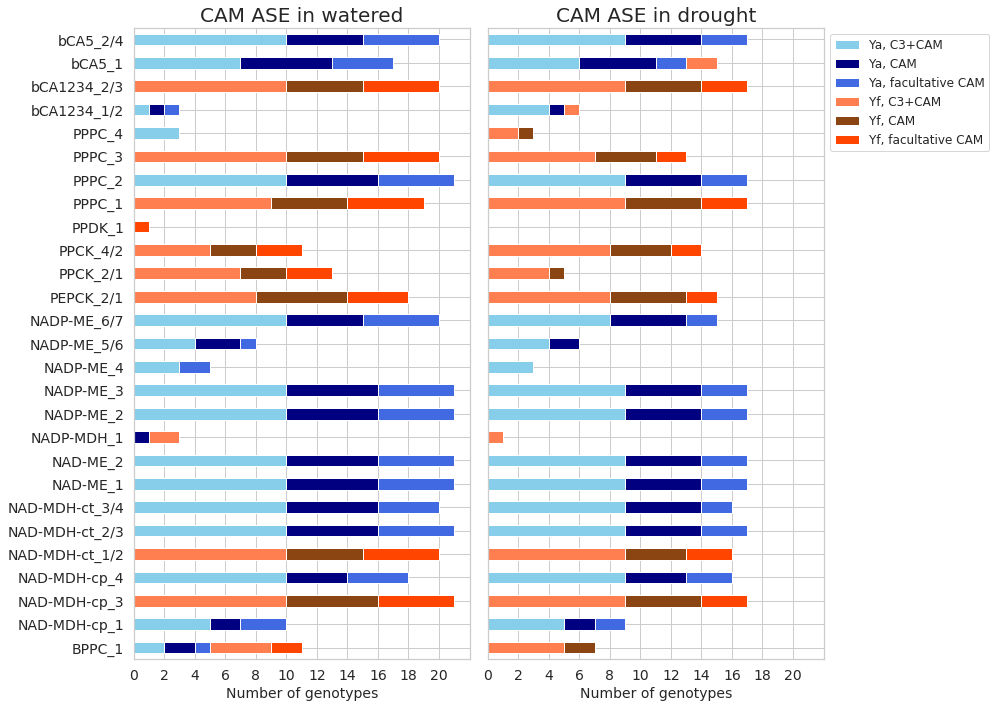

In [95]:
sns.set_theme(style="whitegrid")
fig,ax = plt.subplots(nrows=1,ncols=2,figsize=(14,10),sharey=True,sharex=True)
wplot.plot(kind="barh",ax=ax[0],stacked=True,colormap=LinearSegmentedColormap.from_list("custom",list(custompal.values())))
ax[0].get_legend().remove()
# customize axis labels
ax[0].tick_params(which="both",labelsize=14)
ax[0].set_ylabel("")
ax[0].set_xlabel("Number of genotypes",fontsize=14)
plt.xticks(ticks=range(0,21,2))
ax[0].set_title("CAM ASE in watered",fontsize=20)

dplot.plot(kind="barh",ax=ax[1],stacked=True,colormap=LinearSegmentedColormap.from_list("custom",list(custompal.values())))

# move legend outside plot & customize
plt.legend(bbox_to_anchor=(1,1),labels=["Ya, C3+CAM","Ya, CAM","Ya, facultative CAM",
                                       "Yf, C3+CAM","Yf, CAM","Yf, facultative CAM"],
          fontsize=12)
ax[1].tick_params(which="both",labelsize=14)
ax[1].set_xlabel("Number of genotypes",fontsize=14)
ax[1].set_title("CAM ASE in drought",fontsize=20)
fig.tight_layout()
plt.savefig("./camgenes_ase_gtnum_byphys_treat.png",dpi=200,bbox_inches="tight")
plt.savefig("./camgenes_ase_gtnum_byphys_treat.svg",dpi=200,bbox_inches="tight")
plt.savefig("./camgenes_ase_gtnum_byphys_treat.pdf",dpi=200,bbox_inches="tight")

In [48]:
len(dplot.index)

27

In [49]:
set(wplot.index).difference(set(dplot.index))

set()

In [50]:
set(synnames.values()).difference(set(wplot.index))

{'NAD-MDH-cp_2', 'NADP-ME_1', 'PPCK_6/4', 'PPCK_7/5'}

In [51]:
camhebcounts.head()

,syntelog_name,subgenome,CAMphys,treat,count
0,BPPC_1,Ya,C3+CAM,W,2
1,BPPC_1,Ya,CAM,W,2
2,BPPC_1,Ya,facultative CAM,W,1
3,BPPC_1,Yf,C3+CAM,D,5
4,BPPC_1,Yf,C3+CAM,W,4


In [52]:
hebcamtotals = camhebcounts.groupby(["syntelog_name","subgenome","treat"]).sum().reset_index()

In [53]:
wtotals = hebcamtotals[hebcamtotals["treat"]=="W"].sort_values(by="count",ascending=False)

In [54]:
dtotals = hebcamtotals[hebcamtotals["treat"]=="D"].sort_values(by="count",ascending=False)

In [55]:
wtotals[wtotals["count"]==21]

,syntelog_name,subgenome,treat,count
42,PPPC_2,Ya,W,21
6,NAD-MDH-cp_3,Yf,W,21
25,NADP-ME_3,Ya,W,21
12,NAD-MDH-ct_2/3,Ya,W,21
23,NADP-ME_2,Ya,W,21
16,NAD-ME_1,Ya,W,21
18,NAD-ME_2,Ya,W,21


In [56]:
dtotals[dtotals["count"]==17]

,syntelog_name,subgenome,treat,count
55,bCA5_2/4,Ya,D,17
5,NAD-MDH-cp_3,Yf,D,17
11,NAD-MDH-ct_2/3,Ya,D,17
15,NAD-ME_1,Ya,D,17
17,NAD-ME_2,Ya,D,17
50,bCA1234_2/3,Yf,D,17
22,NADP-ME_2,Ya,D,17
24,NADP-ME_3,Ya,D,17
41,PPPC_2,Ya,D,17
39,PPPC_1,Yf,D,17


In [57]:
hebcam.head()

,GeneID,syntelogID,genotype,treat,subgenome,gene_abbr_unique,gene_abbr,Pathway,syntelog_name,CAMphys
0,Yucal.02G133400.v2.1,recip_syn3801,18,W,Ya,Ya_NADP-ME_2,NADP-ME,CAM-light,NADP-ME_2,C3+CAM
1,Yucal.02G133400.v2.1,recip_syn3801,2AB,W,Ya,Ya_NADP-ME_2,NADP-ME,CAM-light,NADP-ME_2,C3+CAM
2,Yucal.02G133400.v2.1,recip_syn3801,2AB,D,Ya,Ya_NADP-ME_2,NADP-ME,CAM-light,NADP-ME_2,C3+CAM
3,Yucal.02G133400.v2.1,recip_syn3801,1AB,W,Ya,Ya_NADP-ME_2,NADP-ME,CAM-light,NADP-ME_2,C3+CAM
4,Yucal.02G133400.v2.1,recip_syn3801,18,D,Ya,Ya_NADP-ME_2,NADP-ME,CAM-light,NADP-ME_2,C3+CAM


In [58]:
hebcam.to_csv("./ASE_gttreat_CAMresults.txt",sep="\t",header=True,index=False)

In [59]:
wplot.head()

sgphys,Ya_C3+CAM,Ya_CAM,Ya_facultative CAM,Yf_C3+CAM,Yf_CAM,Yf_facultative CAM
syntelog_name,,,,,,
BPPC_1,2.0,2.0,1.0,4.0,0.0,2.0
NAD-MDH-cp_1,5.0,2.0,3.0,0.0,0.0,0.0
NAD-MDH-cp_3,0.0,0.0,0.0,10.0,6.0,5.0
NAD-MDH-cp_4,10.0,4.0,4.0,0.0,0.0,0.0
NAD-MDH-ct_1/2,0.0,0.0,0.0,10.0,5.0,5.0


In [98]:
# re-make this figure with only 4 gene families: May 14, 2026
## first subset wplot & dplot
keepgenes = []
for i in wplot.index:
    if i.startswith("PP"):
        keepgenes.append(i)
    elif i.startswith("BP"):
        keepgenes.append(i)

In [99]:
wp2 = wplot[wplot.index.isin(keepgenes)]
dp2 = dplot[dplot.index.isin(keepgenes)]

In [100]:
order = wp2.index
dp2 = dp2.reindex(order)

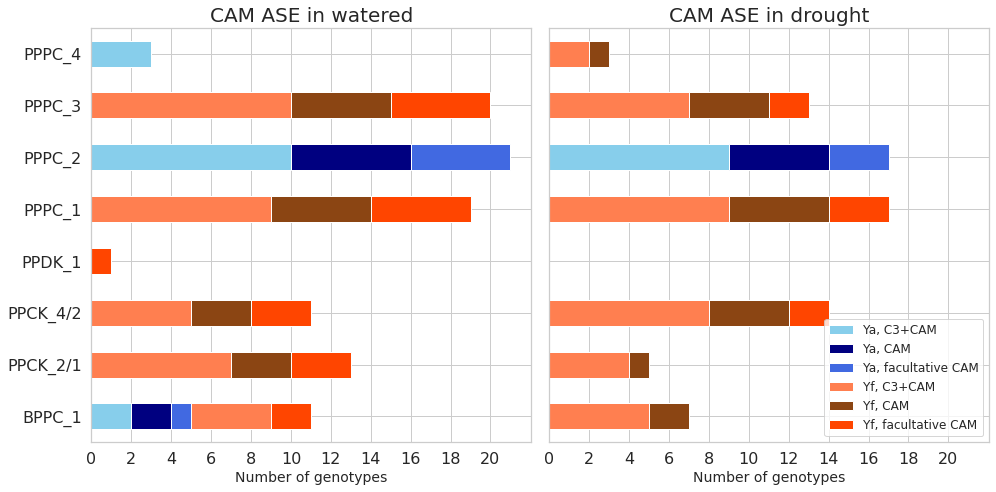

In [104]:
sns.set_theme(style="whitegrid")
fig,ax = plt.subplots(nrows=1,ncols=2,figsize=(14,7),sharey=True,sharex=True)
wp2.plot(kind="barh",ax=ax[0],stacked=True,colormap=LinearSegmentedColormap.from_list("custom",list(custompal.values())))
ax[0].get_legend().remove()
# customize axis labels
ax[0].tick_params(which="both",labelsize=16)
ax[0].set_ylabel("")
ax[0].set_xlabel("Number of genotypes",fontsize=14)
plt.xticks(ticks=range(0,21,2))
ax[0].set_title("CAM ASE in watered",fontsize=20)

dp2.plot(kind="barh",ax=ax[1],stacked=True,colormap=LinearSegmentedColormap.from_list("custom",list(custompal.values())))

# move legend outside plot & customize
plt.legend(loc="lower right",labels=["Ya, C3+CAM","Ya, CAM","Ya, facultative CAM",
                                       "Yf, C3+CAM","Yf, CAM","Yf, facultative CAM"],
          fontsize=12)
ax[1].tick_params(which="both",labelsize=16)
ax[1].set_xlabel("Number of genotypes",fontsize=14)
ax[1].set_title("CAM ASE in drought",fontsize=20)
fig.tight_layout()
plt.savefig("./subcamgenes_ase_gtnum_byphys_treat.png",dpi=200,bbox_inches="tight")
plt.savefig("./subcamgenes_ase_gtnum_byphys_treat.svg",dpi=200,bbox_inches="tight")
plt.savefig("./subcamgenes_ase_gtnum_byphys_treat.pdf",dpi=200,bbox_inches="tight")